In [1]:
import torch
from torch import nn
from torch.nn import functional as f
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from torchmetrics.classification import Accuracy, Recall, BinaryF1Score


In [2]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    
    np.random.seed(seed)        

set_seed(616) 

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的裝置: {device}")

目前使用的裝置: cpu


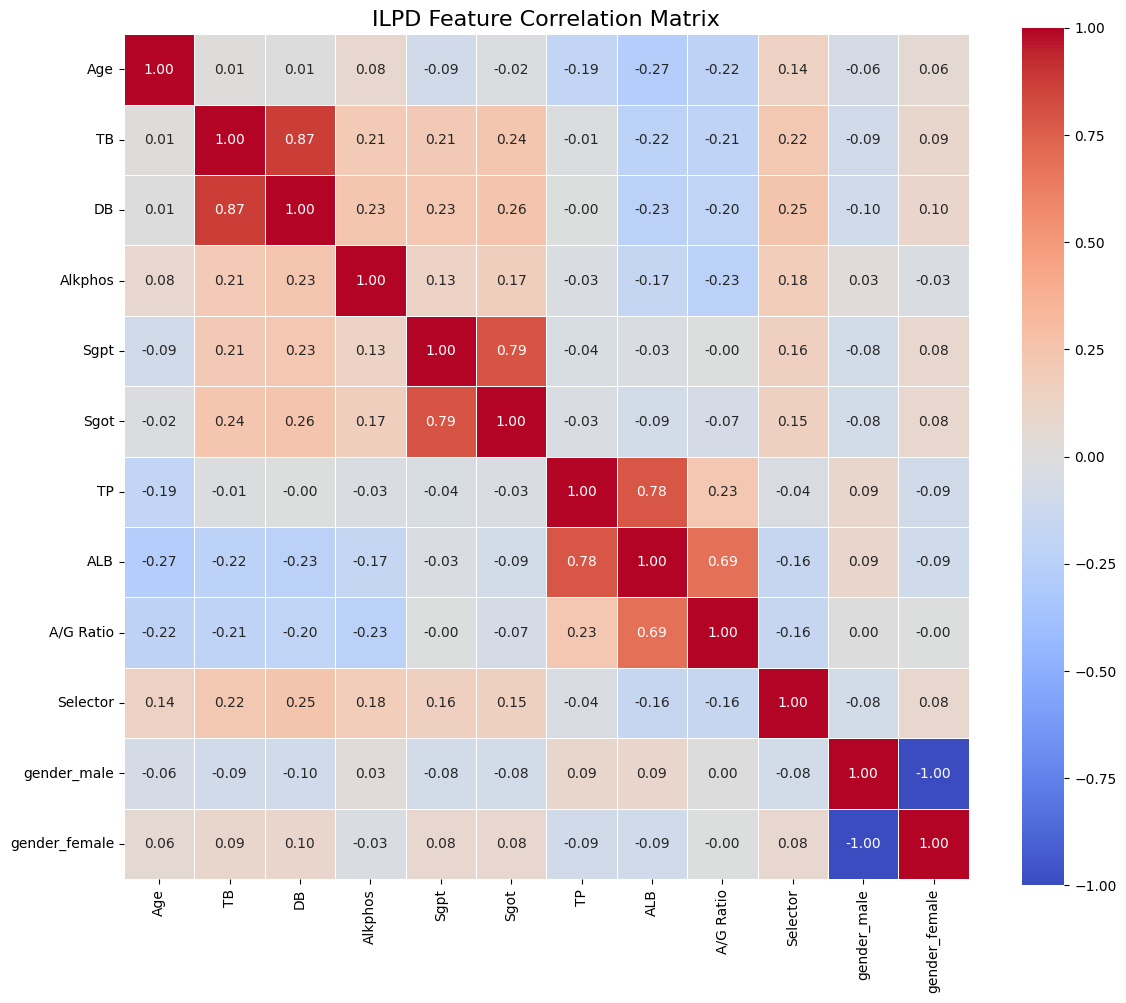

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 計算相關係數矩陣 (假設 df 是您包含 11 維特徵與 Selector 的 DataFrame)
corr_matrix = df.corr()

# 2. 設定畫布大小
plt.figure(figsize=(12, 10))

# 3. 繪製熱圖 (Heatmap)
# vmin/vmax 設定範圍在 -1 到 1，cmap 使用藍紅對比色調
sns.heatmap(
    corr_matrix, 
    annot=True,          # 在格子內顯示數字
    fmt=".2f",          # 小數點後兩位
    cmap="coolwarm",     # 藍色代表負相關，紅色代表正相關
    linewidths=0.5,      # 格子間的線寬
    square=True          # 讓格子保持正方形
)

plt.title("ILPD Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/input/datasets/fatemehmehrparvar/liver-disorders/Indian Liver Patient Dataset (ILPD).csv")
df['A/G Ratio'] = df['A/G Ratio'].fillna(df['A/G Ratio'].mean())

labelencoder = LabelEncoder()
onehotencoder = OneHotEncoder()
df["Gender"] = labelencoder.fit_transform(df["Gender"])
onehot_df = onehotencoder.fit_transform(df[["Gender"]])
onehot_df = pd.DataFrame(onehot_df.toarray(), columns=["gender_male", "gender_female"])
df = pd.concat([df, onehot_df], axis=1)
df = df.drop(columns='Gender')

df['AST_ALT_Ratio'] = df['Sgot'] / (df['Sgpt'] + 1e-5)

features_to_drop = ['DB', 'TP', 'Sgot', 'Sgpt', 'gender_male', 'gender_female']
df_cleaned = df.drop(columns=features_to_drop)

# 3. 提取 6 維特徵與標籤
x = df_cleaned.drop(columns = "Selector").values
y = df["Selector"].values
y[y == 2] = 0 

x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(x, y, test_size=0.2, random_state=621)

m_scaler = MinMaxScaler()
x_train_scaled = m_scaler.fit_transform(x_train_raw)
x_test_scaled = m_scaler.transform(x_test_raw)


x_train = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

x_1 = x_train[(y_train == 1).view(-1)]
x_0 = x_train[(y_train == 0).view(-1)]

# 7. 驗證最終維度
print(f"訓練集特徵形狀: {x_train.shape}") # 預期: [N, 6]
print(f"測試集特徵形狀: {x_test.shape}")  # 預期: [M, 6]
print(f"純訓練集健康樣本 (x_0) shape: {x_0.shape}")
print(f"純訓練集患病樣本 (x_1) shape: {x_1.shape}")

訓練集特徵形狀: torch.Size([466, 6])
測試集特徵形狀: torch.Size([117, 6])
純訓練集健康樣本 (x_0) shape: torch.Size([138, 6])
純訓練集患病樣本 (x_1) shape: torch.Size([328, 6])


In [133]:
class VAE(nn.Module):

    def __init__(self, input_dim=6, hidden_dim=32, latent_dim=4):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = f.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar, alpha=1.0):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + alpha * (eps * std)

    def decode(self, z):
        h = f.relu(self.fc2(z))
        return f.sigmoid(self.fc3(h)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar, alpha=2.0)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight=0.01):
    recon_loss = f.binary_cross_entropy(recon_x, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss

vae_dataset = TensorDataset(x_0)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

VAE_model = VAE()
optimizer = Adam(VAE_model.parameters(), lr=0.001)

epochs = 400

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    kl_weight = min(1.0, epoch / 50.0) * 0.1 

    for batch in vae_loader:
        batch_data = batch[0]
        
        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(batch_data)
        VAEloss, recon_loss, kl_loss = vae_loss(recon, batch_data, mu, logvar, kl_weight)

        VAEloss.backward()
        optimizer.step()
        
        total_VAEloss += VAEloss.item() * len(batch_data)
        total_recon_loss += recon_loss.item() * len(batch_data)
        total_kl_loss += kl_loss.item() * len(batch_data)

    total_samples = len(x_0)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )


Epoch [1/400] Loss: 0.7239 | Recon: 0.7239 | KL: 0.0173 (wt: 0.000)
Epoch [10/400] Loss: 0.6152 | Recon: 0.6147 | KL: 0.0307 (wt: 0.018)
Epoch [20/400] Loss: 0.5450 | Recon: 0.5417 | KL: 0.0869 (wt: 0.038)
Epoch [30/400] Loss: 0.5155 | Recon: 0.5081 | KL: 0.1266 (wt: 0.058)
Epoch [40/400] Loss: 0.4966 | Recon: 0.4884 | KL: 0.1046 (wt: 0.078)
Epoch [50/400] Loss: 0.4833 | Recon: 0.4770 | KL: 0.0637 (wt: 0.098)
Epoch [60/400] Loss: 0.4803 | Recon: 0.4771 | KL: 0.0321 (wt: 0.100)
Epoch [70/400] Loss: 0.4733 | Recon: 0.4712 | KL: 0.0207 (wt: 0.100)
Epoch [80/400] Loss: 0.4700 | Recon: 0.4688 | KL: 0.0121 (wt: 0.100)
Epoch [90/400] Loss: 0.4679 | Recon: 0.4671 | KL: 0.0079 (wt: 0.100)
Epoch [100/400] Loss: 0.4646 | Recon: 0.4641 | KL: 0.0047 (wt: 0.100)
Epoch [110/400] Loss: 0.4642 | Recon: 0.4638 | KL: 0.0036 (wt: 0.100)
Epoch [120/400] Loss: 0.4627 | Recon: 0.4625 | KL: 0.0023 (wt: 0.100)
Epoch [130/400] Loss: 0.4628 | Recon: 0.4627 | KL: 0.0017 (wt: 0.100)
Epoch [140/400] Loss: 0.4652 | 

In [156]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# ==========================================
# 1. 網路架構：嵌入網絡 (Embedding Network)
# ==========================================
class ILPDEmbeddingNet(nn.Module):
    def __init__(self, input_dim=6, embedding_dim=4):
        super().__init__()
        # 使用多層全連接層，將 6 維原始特徵映射到 4 維純淨空間
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )
        
    def forward(self, x):
        features = self.encoder(x)
        # 🌟 關鍵：將輸出進行 L2 正則化，把特徵固定在一個超球面上，這能讓距離計算非常穩定
        return torch.nn.functional.normalize(features, p=2, dim=1)

# ==========================================
# 2. 核心損失函數：在線三元組損失 (Online Triplet Loss)
# ==========================================
class OnlineTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
        
    def forward(self, embeddings, labels):
        """
        在一個 Batch 內自動挖掘所有可能的 (Anchor, Positive, Negative) 組合
        """
        # 計算 Batch 內兩兩樣本之間的歐氏距離平方
        dot_product = torch.matmul(embeddings, embeddings.t())
        square_norm = torch.diag(dot_product)
        distances = square_norm.unsqueeze(0) - 2.0 * dot_product + square_norm.unsqueeze(1)
        distances = torch.clamp(distances, min=0.0) # 預防負數
        
        labels = labels.view(-1, 1)
        # 建立遮罩：哪些是同類 (Positive Mask)，哪些是異類 (Negative Mask)
        mask_pos = torch.eq(labels, labels.t()).float()
        mask_neg = torch.ne(labels, labels.t()).float()
        
        loss = 0.0
        triplet_count = 0
        
        # 遍歷 Batch 內每個樣本作為 Anchor
        for i in range(embeddings.size(0)):
            pos_distances = distances[i][mask_pos[i] == 1]
            neg_distances = distances[i][mask_neg[i] == 1]
            
            if len(pos_distances) > 1 and len(neg_distances) > 0:
                # 為了避免無效組合，這裡會進行有效三元組的拉扯
                # Triplet Formula: Max(0, D(A,P) - D(A,N) + Margin)
                pos_dist_tensor = pos_distances.unsqueeze(1) # [Num_Pos, 1]
                neg_dist_tensor = neg_distances.unsqueeze(0) # [1, Num_Neg]
                
                loss_matrix = pos_dist_tensor - neg_dist_tensor + self.margin
                active_triplets = torch.clamp(loss_matrix, min=0.0)
                
                loss += active_triplets.sum()
                triplet_count += (active_triplets > 0).sum().item()
                
        return loss / (triplet_count + 1e-5)



train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

metric_model = ILPDEmbeddingNet(input_dim=6, embedding_dim=4).to(device)
criterion = OnlineTripletLoss(margin=0.4) # Margin 代表拉開的最小安全邊界
optimizer = optim.AdamW(metric_model.parameters(), lr=0.002, weight_decay=1e-4)

# ==========================================
# 4. 執行訓練迴圈 (Training Loop)
# ==========================================
epochs = 100
metric_model.train()

print("開始訓練深度度量學習網絡...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        embeddings = metric_model(batch_x)
        loss = criterion(embeddings, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Triplet Loss: {epoch_loss/len(train_loader):.4f}")

# 儲存度量學習特徵提取器
torch.save(metric_model.state_dict(), "ilpd_metric_model.pth")
print("度量學習訓練完成，模型已成功存檔！")

開始訓練深度度量學習網絡...
Epoch [1/100] - Triplet Loss: 0.6196
Epoch [10/100] - Triplet Loss: 0.3963
Epoch [20/100] - Triplet Loss: 0.4029
Epoch [30/100] - Triplet Loss: 0.3978
Epoch [40/100] - Triplet Loss: 0.4128
Epoch [50/100] - Triplet Loss: 0.4085
Epoch [60/100] - Triplet Loss: 0.4001
Epoch [70/100] - Triplet Loss: 0.4120
Epoch [80/100] - Triplet Loss: 0.4251
Epoch [90/100] - Triplet Loss: 0.3997
Epoch [100/100] - Triplet Loss: 0.4142
度量學習訓練完成，模型已成功存檔！


In [39]:
def sampling_fn(num_samples=80, device=device):
    """
    從真實健康樣本 (x_0) 的隱空間後驗分佈中進行重抽樣，生成高品質健康樣本。
    """
    if 'VAE_model' in globals(): VAE_model.eval()
    if 'metric_model' in globals(): metric_model.eval()
        
    x_0_dev = x_0.to(device) 
    
    with torch.no_grad():
        mu_0, logvar_0 = VAE_model.encode(x_0_dev)
        std_0 = torch.exp(0.5 * logvar_0)
        

        center_mu = mu_0.mean(dim=0, keepdim=True)
        center_std = std_0.mean(dim=0, keepdim=True)
        
        epsilon = torch.randn(num_samples, center_mu.size(1), device=device)
        z = center_mu + epsilon * center_std

        generated_data = VAE_model.decode(z).detach()


    y_generated = torch.zeros(num_samples, 1, device=device)


    x_train_dev = x_train.to(device)
    y_train_dev = y_train.to(device)

    x_train_sampling = torch.cat((x_train_dev, generated_data), dim=0)
    y_train_sampling = torch.cat((y_train_dev, y_generated), dim=0)

    perm = torch.randperm(x_train_sampling.size(0), device=device)
    x_train_sampling = x_train_sampling[perm]
    y_train_sampling = y_train_sampling[perm]

    return x_train_sampling, y_train_sampling

In [222]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures

_kpca = None
_vae_center = None
_dml_center = None

def data_aug_fn(x, y, test = False):
    global _kpca, _vae_center, _dml_center
    if 'VAE_model' in globals(): VAE_model.eval()
    if 'metric_model' in globals(): metric_model.eval()

    if _kpca is None or _vae_center is None or _dml_center is None:
        
        _kpca = KernelPCA(n_components=3, kernel="rbf", gamma=0.1)
        _kpca.fit(x_train.cpu().numpy())

        healthy_mask = (y_train == 0).flatten()
        x_train_healthy = x_train[healthy_mask].to(x.device)

        with torch.no_grad():
            _vae_center = get_mu(x_train_healthy).mean(dim=0)
            _dml_center = metric_model(x_train_healthy).mean(dim=0)

    with torch.no_grad():

        vae_mu = get_mu(x)
        recon_error = get_recon_error(x) 
        recon_error_max = recon_error.max(dim=1).values.unsqueeze(1) 

        x_em = metric_model(x)

        vae_dist = torch.norm(vae_mu - _vae_center, p = 2, dim = 1, keepdim = True)
        dml_dist = torch.norm(x_em - _dml_center, p = 2, dim = 1, keepdim = True)

        x_kpca_np = _kpca.transform(x.cpu().numpy())
        x_kpca = torch.tensor(x_kpca_np, dtype=torch.float32).to(x.device)

        #x_augmented = torch.cat((x, recon_error, torch.log1p(recon_error_max)), dim=1)
        x_augmented = torch.cat((vae_mu, 
                                 x_em, 
                                 vae_dist, 
                                 dml_dist, 
                                 x_kpca, 
                                 torch.log1p(recon_error_max)), dim=1)
        
    if test:
        x_aug = x_augmented
        y_aug = y
    else:
        perm = torch.randperm(x_augmented.size(0))
        x_aug = x_augmented[perm]
        y_aug = y[perm]
    print(x_aug.shape)
    return x_aug, y_aug


In [13]:
def get_recon_error(x):
    
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
    
    return recon_error

In [69]:
def get_mu(x):
    VAE_model.eval()

    with torch.no_grad():
        mu, _ = VAE_model.encode(x)

    return mu

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


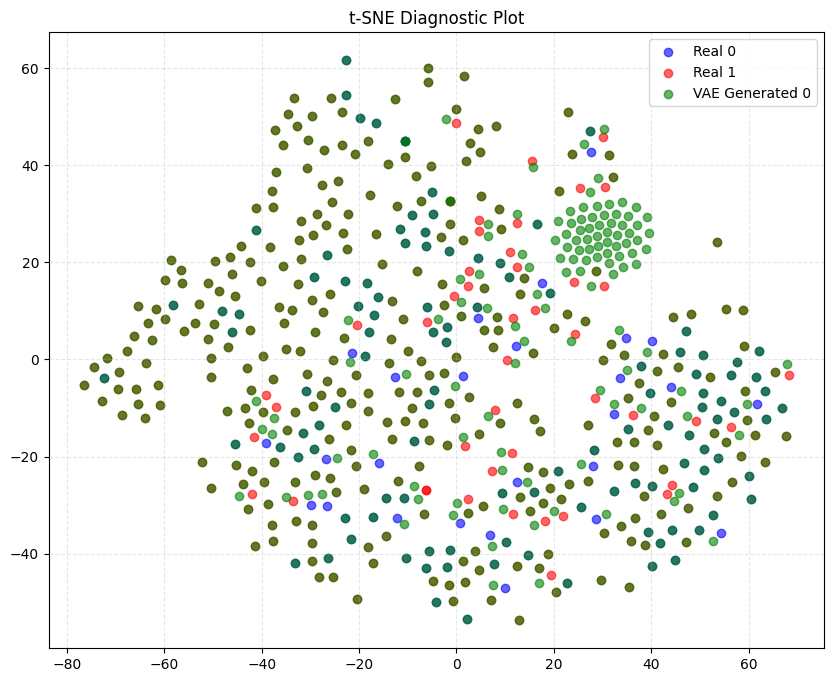

In [142]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

x_vae_0, _ = sampling_fn(50)
X = np.concatenate([x_0, x_1, x_vae_0], axis=0)

y = np.concatenate(
    [
        np.zeros(len(x_0)),
        np.ones(len(x_1)),
        np.ones(len(x_vae_0)) * 2,  
    ]
)


tsne = TSNE(n_components=2, perplexity=80, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
colors = ["blue", "red", "green"]
labels = ["Real 0", "Real 1", "VAE Generated 0"]

for i in range(3):
    idx = y == i
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()
plt.title("t-SNE Diagnostic Plot")
plt.savefig("tsne_diagnostic_plot.png", dpi=300, bbox_inches='tight')
plt.show()

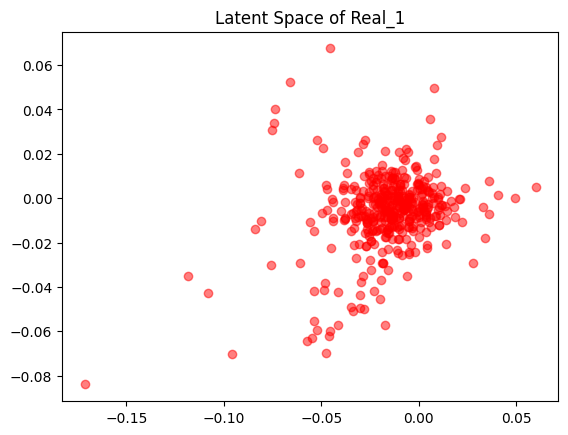

In [12]:
mu_1, _ = VAE_model.encode(x_1)
# 畫出 mu 的散點圖
plt.scatter(mu_1[:, 0].detach(), mu_1[:, 1].detach(), c='red', alpha=0.5)
plt.title("Latent Space of Real_1")
plt.show()

torch.Size([167, 6])


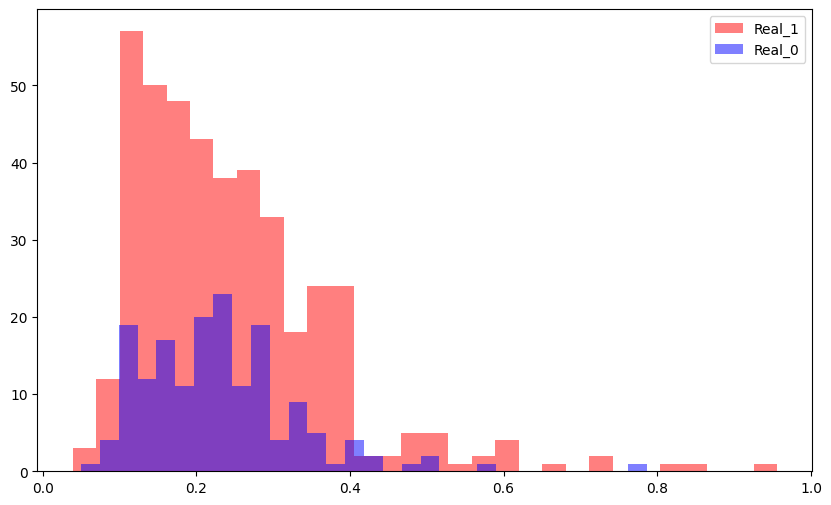

In [14]:
error_0 = get_recon_error(x_0)
error_1 = get_recon_error(x_1)

print(error_0.shape)


error_1_max = error_1.max(dim=1).values
error_0_max = error_0.max(dim=1).values

plt.figure(figsize=(10, 6))

plt.hist(error_1_max, bins=30, alpha=0.5, label='Real_1', color='red')
plt.hist(error_0_max, bins=30, alpha=0.5, label='Real_0', color='blue')
plt.legend()
plt.show()

In [231]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class resBlock(nn.Module):
    """
    更深的專屬殘差塊：內建 Pre-Activation 與 隨機路徑丟棄 (Drop Path)
    """
    def __init__(self, features=32, prob=0.0):
        super().__init__()
        # Pre-Activation 結構：BatchNorm -> ReLU -> Linear
        # 這種設計在網路極深時，能確保恆等映射（Shortcut）的通道完全敞開，梯度回傳最流暢
        self.bn1 = nn.BatchNorm1d(features)
        self.fn1 = nn.Linear(features, features * 4)
        
        self.bn2 = nn.BatchNorm1d(features * 4)
        self.fn2 = nn.Linear(features * 4, features * 4)

        self.bn3 = nn.BatchNorm1d(features * 4)
        self.fn3 = nn.Linear(features * 4, features)
        
        self.dropout = nn.Dropout(0.2) # 搭配隨機深度，將 Dropout 微調至 0.2 即可
        self.prob = prob

    def forward(self, x):
        # 1. 殘差路徑計算 (Pre-Activation)
        out = F.relu(self.bn1(x))
        out = self.dropout(self.fn1(out))
        
        out = F.relu(self.bn2(out))
        out = self.fn2(out)
        
        out = F.relu(self.bn3(out))
        out = self.fn3(out)
        
        # 2. 隨機深度 (Stochastic Depth / Drop Path) 機制
        if self.training and self.prob > 0.0:
            keep_prob = 1.0 - self.prob
            shape = (x.shape[0], 1)
            random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
            binary_tensor = torch.floor(random_tensor) # 隨機產生 0 或 1 的 Mask
            
            # 對殘差分支進行遮罩與期望值縮放
            out = (out / keep_prob) * binary_tensor
            
        # 3. 恆等映射相加
        return x + out

class BranchBlock(nn.Module):
    def __init__(self, features=32, depth=10, max_drop_path=0.3):
        """
        深層分支塊
        - depth: 該分支縱向堆疊的殘差塊數量 (升級至深層)
        - max_drop_path: 隨機深度在該分支最深處的最高丟棄率
        """
        super().__init__()
        # 在分支內部實作隨機深度概率的線性衰減 (Linear Decay Rule)
        # 越往分支深處走，神經元越容易過擬合，因此給予更高的 DropPath 概率
        dpr = [x.item() for x in torch.linspace(0, max_drop_path, depth)]
        
        self.res_layers = nn.ModuleList([
            resBlock(features=features, prob=dpr[i]) for i in range(depth)
        ])
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        for layer in self.res_layers:
            x = layer(x)
        x = self.dropout(x)
        return x

class ElementWeight(nn.Module):
    def __init__(self, features=32):
        super().__init__()
        self.fn1 = nn.Linear(features, features)

    def forward(self, x):
        weights = torch.sigmoid(self.fn1(x))
        return x * weights

class Detection_model(nn.Module):
    def __init__(self, dim=18, features=128, num_resBlocks=12, num_branchs=4, gate=False, max_drop_path=0.3):
        """
        基於原架構的「寬深雙維度完全體」ResNet
        - dim: 18 (對齊你們的18維流形特徵)
        - num_resBlocks: 單一分支的縱向殘差深度 (建議設 10 ~ 20 層)
        - num_branchs: 平行集成的分支數量 (建議設 3 ~ 5 個)
        """
        super().__init__()
        self.input = nn.Linear(dim, features)
        self.bn_in = nn.BatchNorm1d(features)
        
        self.fn1 = nn.Linear(features, features // 4)
        self.bn512_1 = nn.BatchNorm1d(features // 4)

        # 這裡的每一條 Branch 都被升級成縱向超深的 ResNet 骨幹
        self.parallel_branchs = nn.ModuleList([
            BranchBlock(features=features // 4, depth=num_resBlocks, max_drop_path=max_drop_path) 
            for _ in range(num_branchs)
        ])
        
        self.gate = gate
        if self.gate:
            self.weights = ElementWeight(features=features // 4)
        else:
            self.register_parameter('weights', None)
                
        self.fnc2 = nn.Linear(features // 4, features)
        self.bn512_2 = nn.BatchNorm1d(features)
        self.output = nn.Linear(features, 1)

    def forward(self, x):
        x = F.relu(self.bn_in(self.input(x)))
        x_bottleneck = F.relu(self.bn512_1(self.fn1(x)))

        # 多路深層特徵平行集成
        parallel = sum(blocks(x_bottleneck) for blocks in self.parallel_branchs)
        
        if self.gate:
            parallel = self.weights(parallel)
        
        x_residual = x_bottleneck + parallel 

        x_out = F.relu(self.bn512_2(self.fnc2(x_residual)))
        logits = self.output(x_out)
        return logits

    def prediction(self, x):
        return torch.sigmoid(self.forward(x))

class NN(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.input = nn.Linear(dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fn = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = f.relu(self.bn1(self.input(x)))
        x = f.relu(self.bn2(self.fn(x)))
        x = self.output(x)

        return x
        
print("ok")

ok


In [232]:
mode = 9


if mode == 0:
    training_data = x_train
    target = y_train
    detection_model = NN(dim = 11)
    
elif mode == 1:
    training_data, target = sampling_fn()
    detection_model = NN(dim = 11)
    
elif mode == 2:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = NN(dim = 22)
    
elif mode == 3:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = NN(dim = 22)
    
elif mode == 4:
    training_data = x_train
    target = y_train
    detection_model = Detection_model(dim = 11)
    
elif mode == 5:
    training_data, target = sampling_fn()
    detection_model = Detection_model(dim = 11)
    
elif mode == 6:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22)
    
elif mode == 7:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22, gate = True)

elif mode == 8:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22)
elif mode == 9:
    x_sample, y_sample = sampling_fn()
    training_data, target = data_aug_fn(x_train, y_train)
    dim = training_data.shape[1]

    detection_model = Detection_model(dim = dim, features = 128, num_resBlocks = 15, num_branchs = 4, gate = True)
    detection_model = detection_model.to(device)
else:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22, gate = False)

pass
train_dataset = TensorDataset(training_data, target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#detection_model = Detection_model(num_resBlocks = 20, num_branchs = 5)
optim = AdamW(detection_model.parameters(), lr = 0.0001, weight_decay=0.05)

scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.3, patience=10)

accuracy = Accuracy(task = "binary").to(device)
recall = Recall(task="binary").to(device)
f1 = BinaryF1Score().to(device)

epochs = 300

num_neg = (target == 0).sum().float()
num_pos = (target == 1).sum().float()
#pos_weight = torch.tensor([num_neg / num_pos])
pos_weight = torch.tensor([0.33]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

for epoch in range(epochs):
    detection_model.train()
    total_loss = 0
    
    epoch_preds = []
    epoch_targets = []

    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        y_pred_logits = detection_model(batch_x)
        
        y_pred_logits = y_pred_logits.squeeze() 
        batch_y = batch_y.squeeze()

        loss = loss_fn(y_pred_logits, batch_y)
        loss.backward()
        optim.step()

        total_loss += loss.item() * len(batch_y)
        
        y_pred_prob = torch.sigmoid(y_pred_logits)
        epoch_preds.append(y_pred_prob.detach())
        epoch_targets.append(batch_y.detach())
        
    avg_loss = total_loss / len(training_data)

    torch.nn.utils.clip_grad_norm_(detection_model.parameters(), max_norm=1.0)
    scheduler.step(avg_loss)
    
    all_preds = torch.cat(epoch_preds)
    all_targets = torch.cat(epoch_targets)
    
    acc_score = accuracy(all_preds, all_targets)
    recall_score = recall(all_preds, all_targets)
    
    if (epoch+1) % 10 == 0:
        
        current_lr = optim.param_groups[0]['lr']
        print(f"epoch:[{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc: {acc_score:.4f}  recall:{recall_score:.4f}  lr:{current_lr:.10f}") 


torch.Size([466, 14])
epoch:[10/300]  loss: 0.2702  acc: 0.7468  recall:0.7073  lr:0.0001000000
epoch:[20/300]  loss: 0.2482  acc: 0.7618  recall:0.7439  lr:0.0001000000
epoch:[30/300]  loss: 0.2390  acc: 0.7833  recall:0.7470  lr:0.0001000000
epoch:[40/300]  loss: 0.2192  acc: 0.7704  recall:0.7378  lr:0.0001000000
epoch:[50/300]  loss: 0.2076  acc: 0.7918  recall:0.7530  lr:0.0001000000
epoch:[60/300]  loss: 0.2067  acc: 0.7768  recall:0.7348  lr:0.0001000000
epoch:[70/300]  loss: 0.1859  acc: 0.7961  recall:0.7439  lr:0.0001000000
epoch:[80/300]  loss: 0.1907  acc: 0.8197  recall:0.7744  lr:0.0001000000
epoch:[90/300]  loss: 0.1844  acc: 0.8026  recall:0.7500  lr:0.0001000000
epoch:[100/300]  loss: 0.1744  acc: 0.8090  recall:0.7561  lr:0.0000300000
epoch:[110/300]  loss: 0.1780  acc: 0.8047  recall:0.7500  lr:0.0000300000
epoch:[120/300]  loss: 0.1652  acc: 0.8283  recall:0.7805  lr:0.0000090000
epoch:[130/300]  loss: 0.1719  acc: 0.8283  recall:0.7805  lr:0.0000027000
epoch:[140/3

In [233]:
if mode not in {0,1,4,5,9} :
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x_test)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x_test - x_hat)
        x_augmented = torch.cat((x_test, recon_error), dim=1) 
    dataset = TensorDataset(x_augmented, y_test)

else:
    VAE_model.eval()
    with torch.no_grad():
        
        x_aug, y_aug = data_aug_fn(x_test, y_test, test = True)
        
        dataset = TensorDataset(x_aug, y_aug)
loader = DataLoader(dataset, batch_size=16, shuffle=False) 

all_preds = []
all_targets = []

detection_model.eval()

with torch.no_grad():
    for batch_x, batch_y in loader:

        batch_x, batch_y=batch_x.to(device), batch_y.to(device)
        y_logits = detection_model(batch_x)
        prob = torch.sigmoid(y_logits).flatten()
        
        y_pred = (prob >= 0.0210).int()
        
        all_preds.append(y_pred.view(-1).cpu())
        all_targets.append(batch_y.view(-1).cpu())

final_preds = torch.cat(all_preds, dim=0)
final_targets = torch.cat(all_targets, dim=0).int()

accuracy.reset()
recall.reset()
f1.reset()
metric_acc = accuracy(final_preds, final_targets)
metric_recall = recall(final_preds, final_targets)
metric_f1 = f1(final_preds, final_targets)

print(f"--- 全測試集評估結果 ---")
print(f"Accuracy: {metric_acc.item():.4f}")
print(f"Recall:   {metric_recall.item():.4f}")
print(f"f1 score: {metric_f1.item():.4f}")

print("\n預測的前 50 筆結果:")
print(final_preds[:50].cpu().numpy()) 

torch.Size([117, 14])
--- 全測試集評估結果 ---
Accuracy: 0.7521
Recall:   1.0000
f1 score: 0.8585

預測的前 50 筆結果:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [185]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test.view(-1, 1), final_targets))

[[ 7 22]
 [22 66]]


torch.Size([117, 14])
🎯 18維完全體最佳流形防禦決策點定案：
   -> 最佳分類門檻值 (Threshold): 0.0601
   -> 當前 Recall (疾病捕捉率)  : 98.86%
   -> 當前 Precision (精準度)  : 76.99%


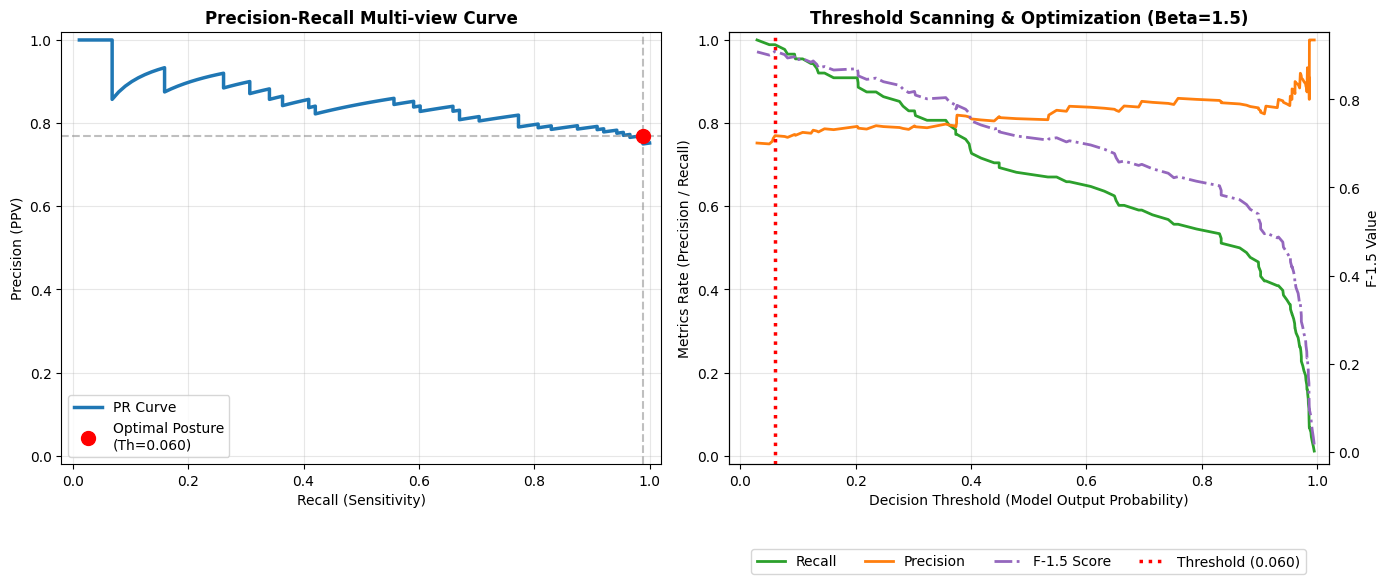

In [234]:
import torch
import matplotlib.pyplot as plt

# ========================================================
# 1. 安全推理：請將下方 'model' 替換為你們真正的 18維模型變數名稱
# ========================================================
# 假設你們的模型變數名稱叫 model (如果是其他名字，請把等號左邊改掉，例如 clf = model)
current_classifier = detection_model 

# 確保模型進入評估模式，關閉梯度
current_classifier.eval()
with torch.no_grad():
    x_aug, y_aug = data_aug_fn(x_test, y_test, test = True)
    logits = current_classifier(x_aug)
    prob = torch.sigmoid(logits)

# 💡 核心防錯：在繪圖前，用 .squeeze() 與 .flatten() 徹底把維度壓扁成 1D
y_aug_flat = y_aug.squeeze().flatten()
prob_flat = prob.squeeze().flatten()

# ========================================================
# 2. 封裝完整的繪圖函數 (內建嚴格的 ax1, ax2 區域變數隔離，絕不噴錯)
# ========================================================
def safe_compute_and_plot(y_true, y_scores, target_recall=0.90, beta=1.5):
    device = y_scores.device
    y_true = y_true.to(device).float()
    
    # 矩陣化滑動門檻計算
    sorted_scores, indices = torch.sort(y_scores, descending=True)
    sorted_true = y_true[indices]
    
    tp_cumsum = torch.cumsum(sorted_true, dim=0)
    fp_cumsum = torch.cumsum(1.0 - sorted_true, dim=0)
    total_positives = sorted_true.sum()
    
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-8)
    recalls = tp_cumsum / (total_positives + 1e-8)
    
    beta_sq = beta ** 2
    f_beta = (1 + beta_sq) * (precisions * recalls) / ((beta_sq * precisions) + recalls + 1e-8)
    
    # 尋找黃金防禦門檻
    valid_mask = recalls >= target_recall
    if not valid_mask.any():
        best_idx = torch.argmax(recalls)
    else:
        valid_indices = torch.where(valid_mask)[0]
        best_valid_idx = torch.argmax(f_beta[valid_indices])
        best_idx = valid_indices[best_valid_idx]
        
    best_th = sorted_scores[best_idx].item()
    opt_precision = precisions[best_idx].item()
    opt_recall = recalls[best_idx].item()
    
    th_np = sorted_scores.cpu().numpy()
    p_np = precisions.cpu().numpy()
    r_np = recalls.cpu().numpy()
    f_np = f_beta.cpu().numpy()
    
    print(f"==================================================")
    print(f"🎯 18維完全體最佳流形防禦決策點定案：")
    print(f"   -> 最佳分類門檻值 (Threshold): {best_th:.4f}")
    print(f"   -> 當前 Recall (疾病捕捉率)  : {opt_recall*100:.2f}%")
    print(f"   -> 當前 Precision (精準度)  : {opt_precision*100:.2f}%")
    print(f"==================================================")
    
    # 開始畫圖
    plt.figure(figsize=(14, 6))
    
    # 左圖：PR 曲線
    plt.subplot(1, 2, 1)
    plt.plot(r_np, p_np, label='PR Curve', color='#1f77b4', lw=2.5)
    plt.scatter(opt_recall, opt_precision, color='red', s=100, zorder=5,
                label=f'Optimal Posture\n(Th={best_th:.3f})')
    plt.axhline(y=opt_precision, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=opt_recall, color='gray', linestyle='--', alpha=0.5)
    plt.title('Precision-Recall Multi-view Curve', fontsize=12, fontweight='bold')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (PPV)')
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower left')
    
    # 右圖：雙 Y 軸門檻掃描 (確保 ax1, ax2 都在同一個局部作用域內明確定義)
    ax1 = plt.subplot(1, 2, 2)
    ax2 = ax1.twinx()  # 雙 Y 軸綁定
    
    line1 = ax1.plot(th_np, r_np, label='Recall', color='#2ca02c', lw=2)
    line2 = ax1.plot(th_np, p_np, label='Precision', color='#ff7f0e', lw=2)
    line3 = ax2.plot(th_np, f_np, label=f'F-{beta} Score', color='#9467bd', lw=2, linestyle='-.')
    
    # 畫出垂直黃金門檻線
    line4 = ax1.axvline(x=best_th, color='red', linestyle=':', lw=2.5, label=f'Threshold ({best_th:.3f})')
    
    ax1.set_title(f'Threshold Scanning & Optimization (Beta={beta})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Decision Threshold (Model Output Probability)')
    ax1.set_ylabel('Metrics Rate (Precision / Recall)')
    ax2.set_ylabel(f'F-{beta} Value')
    
    # 合併所有圖例，使用正確的 bbox_to_anchor
    all_lines = line1 + line2 + line3 + [line4]
    all_labels = [l.get_label() for l in all_lines]
    ax1.legend(all_lines, all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)
    
    ax1.set_xlim([-0.02, 1.02])
    ax1.set_ylim([-0.02, 1.02])
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return best_th

# ========================================================
# 3. 直接跑！
# ========================================================
optimal_threshold = safe_compute_and_plot(
    y_true=y_aug_flat, 
    y_scores=prob_flat, 
    target_recall=0.90, 
    beta=1.5
)